In [1]:
import sys
import warnings
sys.path.append('..')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

SEED = 42
TARGET_NAMES = ['Dropout', 'Enrolled', 'Graduate']

df_clean = pd.read_csv("../data/processed/data_final.csv")
y = df_clean['Target']
X = df_clean.drop(columns=['Target'])

ALL_FEATURES = X.columns.tolist()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

CAT_COLS = ['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
for col in CAT_COLS:
    X_train_raw[col] = X_train_raw[col].astype(str)
    X_test_raw[col] = X_test_raw[col].astype(str)

te = TargetEncoder(cols=CAT_COLS, smoothing=10)
X_tr = te.fit_transform(X_train_raw, y_train)
X_te = te.transform(X_test_raw)

sc = StandardScaler()
X_tr_sc = pd.DataFrame(sc.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
X_te_sc = pd.DataFrame(sc.transform(X_te),     columns=X_te.columns, index=X_te.index)

X_tr_full = X_tr_sc.values
X_te_full = X_te_sc.values
y_tr_np   = y_train.values

X_base, X_dsel, y_base, y_dsel = train_test_split(
    X_tr_full, y_tr_np, test_size=0.30, stratify=y_tr_np, random_state=SEED
)

In [2]:
from src.models_pool import FeatureSubsetWrapper

pool_xgb = joblib.load('../models/specialist_enrolled_xgb.pkl')
pool_svm = joblib.load('../models/specialist_graduate_svm.pkl')
pool_nb  = joblib.load('../models/specialist_dropout_nb.pkl')

meta_idx = joblib.load('../models/specialist_feature_indices.pkl')

wrapped_xgb = FeatureSubsetWrapper(pool_xgb, meta_idx['xgb_idx'])
wrapped_svm = FeatureSubsetWrapper(pool_svm, meta_idx['svm_idx'])
wrapped_nb  = FeatureSubsetWrapper(pool_nb,  meta_idx['nb_idx'])

pool_specialist = [wrapped_xgb, wrapped_svm, wrapped_nb]


In [3]:
from sklearn.neighbors import NearestNeighbors

def dcs_lca_predict(pool, X_dsel, y_dsel, X_test, k=7):
    X_dsel_arr = np.array(X_dsel)
    X_test_arr = np.array(X_test)
    y_dsel_arr = np.array(y_dsel)

    nn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
    nn.fit(X_dsel_arr)
    _, nbr_idx = nn.kneighbors(X_test_arr)

    final_preds = []
    for i, neighbors in enumerate(nbr_idx):
        y_nbr = y_dsel_arr[neighbors]
        X_nbr = X_dsel_arr[neighbors]
        x_i   = X_test_arr[i:i+1]
        best_lca, best_pred = -1.0, None
        for clf in pool:
            pred_class = clf.predict(x_i)[0]
            mask = y_nbr == pred_class
            lca  = np.mean(clf.predict(X_nbr[mask]) == y_nbr[mask]) if mask.sum() > 0 else 0.0
            if lca > best_lca:
                best_lca, best_pred = lca, pred_class
        final_preds.append(best_pred)
    return np.array(final_preds)

--- K Tuning (pool_specialist) ---
  k= 3 | F1 Macro:0.8483 | Dropout:0.9065  Enrolled:0.6846  Graduate:0.9538
  k= 5 | F1 Macro:0.8565 | Dropout:0.9157  Enrolled:0.7013  Graduate:0.9525
  k= 7 | F1 Macro:0.8638 | Dropout:0.9130  Enrolled:0.7261  Graduate:0.9524
  k= 9 | F1 Macro:0.8595 | Dropout:0.9104  Enrolled:0.7170  Graduate:0.9512
  k=11 | F1 Macro:0.8595 | Dropout:0.9104  Enrolled:0.7170  Graduate:0.9512
  k=13 | F1 Macro:0.8595 | Dropout:0.9104  Enrolled:0.7170  Graduate:0.9512
  k=15 | F1 Macro:0.8595 | Dropout:0.9104  Enrolled:0.7170  Graduate:0.9512
  k=17 | F1 Macro:0.8595 | Dropout:0.9104  Enrolled:0.7170  Graduate:0.9512
  k=19 | F1 Macro:0.8595 | Dropout:0.9104  Enrolled:0.7170  Graduate:0.9512
  k=21 | F1 Macro:0.8595 | Dropout:0.9104  Enrolled:0.7170  Graduate:0.9512

Best Values of K : 7 with F1 Macro: 0.8638


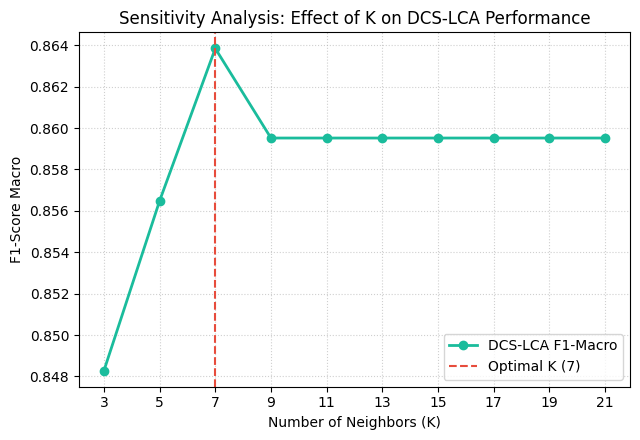

In [4]:
import matplotlib.pyplot as plt 

print("--- K Tuning (pool_specialist) ---")
best_k, best_f1_k = 3, 0.0

k_values = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
f1_macro_history = []

for k in k_values:
    preds_k = dcs_lca_predict(pool_specialist, X_dsel, y_dsel, X_te_full, k=k)
    f1_k    = f1_score(y_test, preds_k, average='macro')
    f1_k_c  = f1_score(y_test, preds_k, average=None)
    f1_macro_history.append(f1_k)
    
    print(f"  k={k:2d} | F1 Macro:{f1_k:.4f} | Dropout:{f1_k_c[0]:.4f}  Enrolled:{f1_k_c[1]:.4f}  Graduate:{f1_k_c[2]:.4f}")
    if f1_k > best_f1_k:
        best_f1_k, best_k = f1_k, k

print(f"\nBest Values of K : {best_k} with F1 Macro: {best_f1_k:.4f}")

plt.figure(figsize=(6.5, 4.5))
plt.plot(k_values, f1_macro_history, marker='o', linestyle='-', color='#1abc9c', linewidth=2, label='DCS-LCA F1-Macro')
plt.axvline(x=best_k, color='#e74c3c', linestyle='--', label=f'Optimal K ({best_k})')
plt.title('Sensitivity Analysis: Effect of K on DCS-LCA Performance')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('F1-Score Macro')
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig('../output/dcs_lca_sensitivity_k.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
def dcs_lca_predict_proba(pool, X_dsel, y_dsel, X_test, k=7):
    """Fungsi kustom untuk mengambil matriks probabilitas (soft-outputs) 
    dari kompeten estimator yang ditunjuk oleh DCS-LCA per sampel data."""
    X_dsel_arr = np.array(X_dsel)
    X_test_arr = np.array(X_test)
    y_dsel_arr = np.array(y_dsel)

    nn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
    nn.fit(X_dsel_arr)
    _, nbr_idx = nn.kneighbors(X_test_arr)

    final_probas = []
    for i, neighbors in enumerate(nbr_idx):
        y_nbr = y_dsel_arr[neighbors]
        X_nbr = X_dsel_arr[neighbors]
        x_i   = X_test_arr[i:i+1]
        
        best_lca = -1.0
        chosen_clf = None
        
        for clf in pool:
            pred_class = clf.predict(x_i)[0]
            mask = y_nbr == pred_class
            lca  = np.mean(clf.predict(X_nbr[mask]) == y_nbr[mask]) if mask.sum() > 0 else 0.0
            if lca > best_lca:
                best_lca = lca
                chosen_clf = clf
                
        proba_i = chosen_clf.predict_proba(x_i)[0]
        final_probas.append(proba_i)
        
    return np.array(final_probas)

y_proba_dcs = dcs_lca_predict_proba(pool_specialist, X_dsel, y_dsel, X_test=X_te_full, k=best_k)

FINAL EVALUATION: DCS-LCA (k=7)
Accuracy  : 0.9162
Log Loss  : 0.2687
ROC-AUC   : 0.9785 (One-vs-Rest Macro)
------------------------------------------------------------
F1 per class -> Dropout:0.9130  Enrolled:0.7261  Graduate:0.9524
F1 Macro     : 0.8638

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.95      0.88      0.91       216
    Enrolled       0.68      0.78      0.73        73
    Graduate       0.94      0.96      0.95       427

    accuracy                           0.92       716
   macro avg       0.86      0.87      0.86       716
weighted avg       0.92      0.92      0.92       716



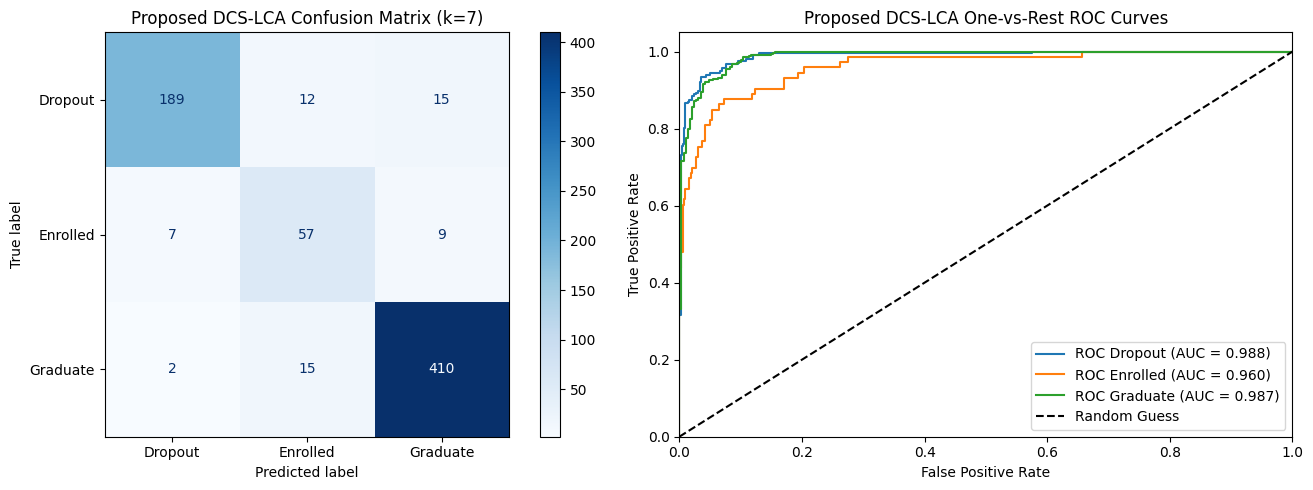

In [7]:
from sklearn.metrics import log_loss, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt 

y_pred_dcs = dcs_lca_predict(pool_specialist, X_dsel, y_dsel, X_te_full, k=best_k)

loss_dcs    = log_loss(y_test, y_proba_dcs)
roc_auc_dcs = roc_auc_score(y_test, y_proba_dcs, multi_class='ovr', average='macro')

print("="*60)
print(f"FINAL EVALUATION: DCS-LCA (k={best_k})")
print("="*60)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_dcs):.4f}")
print(f"Log Loss  : {loss_dcs:.4f}")
print(f"ROC-AUC   : {roc_auc_dcs:.4f} (One-vs-Rest Macro)")
print("-" * 60)

f1_dcs = f1_score(y_test, y_pred_dcs, average=None)
print(f"F1 per class -> Dropout:{f1_dcs[0]:.4f}  Enrolled:{f1_dcs[1]:.4f}  Graduate:{f1_dcs[2]:.4f}")
print(f"F1 Macro     : {f1_score(y_test, y_pred_dcs, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dcs, target_names=TARGET_NAMES))

cm = confusion_matrix(y_test, y_pred_dcs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
disp.plot(cmap=plt.cm.Blues, ax=axes[0], values_format='d')
axes[0].set_title(f"Proposed DCS-LCA Confusion Matrix (k={best_k})")

y_test_bin = pd.get_dummies(y_test).values
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_dcs[:, i])
    roc_auc     = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'ROC {TARGET_NAMES[i]} (AUC = {roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Proposed DCS-LCA One-vs-Rest ROC Curves')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig('../output/dcs_lca_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
import joblib

dcs_lca_model_data = {
    'pool_specialist': pool_specialist,
    'X_dsel': X_dsel,
    'y_dsel': y_dsel,
    'best_k': best_k,
    'target_names': TARGET_NAMES
}

joblib.dump(dcs_lca_model_data, '../models/dcs_lca_model.pkl')


['../models/dcs_lca_model.pkl']